# 07 – Feature Contribution and Scientific Pattern Agreement

## Objective

This notebook investigates whether the predictive patterns identified by the machine-learning models are supported by multiple independent analyses and by the underlying astronomical data.

Notebook 03 established the Random Forest as the selected final classifier.

Notebook 04 investigated how the selected model behaves and which features it relies on.

Notebook 05 investigated the reliability of model probability outputs.

Notebook 06 investigated generalization across different data partitions and performance across subgroups.

This notebook focuses on feature contribution and scientific interpretation.

The central question is:

> Do the model's conclusions agree with independent feature analyses and the underlying astronomical data?

The analysis is divided into five parts:

1. **Feature ablation**  
   Evaluate how model performance changes when individual stellar features are removed.

2. **Single-feature and feature-combination models**  
   Determine whether features are individually predictive, complementary, or redundant.

3. **SHAP interpretation**  
   Examine global feature contribution, individual predictions, and the direction of feature influence.

4. **Direct data analysis**  
   Compare the actual distributions and observed gas-giant frequencies across stellar-property values without relying on a machine-learning model.

5. **Interpretation agreement**  
   Compare evidence from Random Forest importance, permutation importance, SHAP, feature ablation, feature-combination models, and direct data patterns.

The goal is not to force all analyses to produce identical rankings.

Instead, the goal is to determine whether multiple independent approaches broadly support similar scientific conclusions.

Feature importance and predictive associations do not establish causation. The analyses in this notebook describe relationships present in the fitted models and observed dataset.

In [36]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.inspection import permutation_importance

## Reproducibility Configuration

The analyses in this notebook use the same three host-star features and the same fixed Random Forest configuration selected during model development.

No new hyperparameter optimization is performed.

The purpose of this notebook is to investigate feature contribution and scientific pattern agreement, not to select a new final model.

In [37]:
RANDOM_STATE = 42

FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

TARGET = "gas_giant"

N_SPLITS = 5

## Load the Modeling Dataset

The complete modeling dataset is reconstructed from the training and testing partitions created during Notebook 02.

The original train/test partition remains important for final model evaluation.

For feature-ablation and feature-combination comparisons, cross-validation is used so that each alternative feature set is evaluated using the same general validation procedure.

In [38]:
X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

X = pd.concat(
    [
        X_train,
        X_test
    ],
    ignore_index=True
)

y = pd.concat(
    [
        y_train,
        y_test
    ],
    ignore_index=True
)

print("Full modeling dataset shape:", X.shape)
print("Target shape:", y.shape)

Full modeling dataset shape: (27540, 3)
Target shape: (27540,)


In [39]:
assert list(X.columns) == FEATURES
assert len(X) == len(y)
assert set(y.unique()) <= {0, 1}

print(
    "Missing values in modeling features:",
    X.isna().sum().sum()
)

print(
    "Dataset integrity checks passed."
)

Missing values in modeling features: 10359
Dataset integrity checks passed.


## Load the Final Random Forest Configuration

The Random Forest configuration is loaded from the final model selected in Notebook 03.

The model is used as the reference model for the feature-ablation and feature-combination analyses.

The configuration is kept fixed across feature sets so that changes in performance can be attributed to the available features rather than to additional hyperparameter optimization.

In [40]:
best_model = joblib.load(
    "../models/random_forest.joblib"
)

final_rf = best_model.named_steps[
    "model"
]

final_rf_parameters = {
    parameter: value
    for parameter, value in final_rf.get_params().items()
    if parameter in [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "class_weight",
        "random_state"
    ]
}

final_rf_parameters

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100,
 'random_state': 42}

# Feature Ablation

Feature ablation evaluates how model performance changes when individual features are removed.

The following feature sets are compared:

- All three features
- Without stellar effective temperature
- Without stellar radius
- Without stellar metallicity

The key question is:

> Does removing a feature meaningfully reduce predictive performance?

A feature that is important to the model should generally produce some measurable performance change when removed.

However, a small performance decrease does not necessarily mean that a feature is scientifically unimportant. Another feature may contain overlapping or redundant information.

Each feature set is evaluated using the same five-fold stratified cross-validation procedure and the same fixed Random Forest configuration.

In [41]:
feature_sets_ablation = {
    "All Features": [
        "st_teff",
        "st_rad",
        "st_met"
    ],

    "Without st_teff": [
        "st_rad",
        "st_met"
    ],

    "Without st_rad": [
        "st_teff",
        "st_met"
    ],

    "Without st_met": [
        "st_teff",
        "st_rad"
    ]
}

feature_sets_ablation

{'All Features': ['st_teff', 'st_rad', 'st_met'],
 'Without st_teff': ['st_rad', 'st_met'],
 'Without st_rad': ['st_teff', 'st_met'],
 'Without st_met': ['st_teff', 'st_rad']}

In [42]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [43]:
ablation_results = []

for feature_set_name, feature_list in feature_sets_ablation.items():

    model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    **final_rf_parameters
                )
            )
        ]
    )

    results = cross_validate(
        model,
        X[feature_list],
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    ablation_results.append({
        "Feature Set": feature_set_name,
        "Features": ", ".join(feature_list),
        "Accuracy": results[
            "test_accuracy"
        ].mean(),

        "Precision": results[
            "test_precision"
        ].mean(),

        "Recall": results[
            "test_recall"
        ].mean(),

        "F1": results[
            "test_f1"
        ].mean(),

        "ROC-AUC": results[
            "test_roc_auc"
        ].mean(),

        "Average Precision": results[
            "test_average_precision"
        ].mean()
    })

ablation_results = pd.DataFrame(
    ablation_results
)

ablation_results.round(4)

,Feature Set,Features,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,All Features,"st_teff, st_rad, st_met",0.8581,0.5229,0.5898,0.5537,0.8648,0.5805
1,Without st_teff,"st_rad, st_met",0.7926,0.3767,0.5971,0.4617,0.8083,0.4795
2,Without st_rad,"st_teff, st_met",0.7825,0.3667,0.6307,0.4636,0.8003,0.5056
3,Without st_met,"st_teff, st_rad",0.8459,0.4866,0.5935,0.5345,0.8531,0.5646


In [44]:
ablation_results_with_change = (
    ablation_results
    .copy()
)

reference_f1 = (
    ablation_results
    .loc[
        ablation_results["Feature Set"]
        == "All Features",
        "F1"
    ]
    .iloc[0]
)

reference_roc_auc = (
    ablation_results
    .loc[
        ablation_results["Feature Set"]
        == "All Features",
        "ROC-AUC"
    ]
    .iloc[0]
)

ablation_results_with_change[
    "F1 Change vs All Features"
] = (
    ablation_results_with_change["F1"]
    - reference_f1
)

ablation_results_with_change[
    "ROC-AUC Change vs All Features"
] = (
    ablation_results_with_change["ROC-AUC"]
    - reference_roc_auc
)

ablation_results_with_change.round(4)

,Feature Set,Features,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,F1 Change vs All Features,ROC-AUC Change vs All Features
0,All Features,"st_teff, st_rad, st_met",0.8581,0.5229,0.5898,0.5537,0.8648,0.5805,0.0000,0.0000
1,Without st_teff,"st_rad, st_met",0.7926,0.3767,0.5971,0.4617,0.8083,0.4795,-0.0920,-0.0565
2,Without st_rad,"st_teff, st_met",0.7825,0.3667,0.6307,0.4636,0.8003,0.5056,-0.0901,-0.0645
3,Without st_met,"st_teff, st_rad",0.8459,0.4866,0.5935,0.5345,0.8531,0.5646,-0.0191,-0.0117


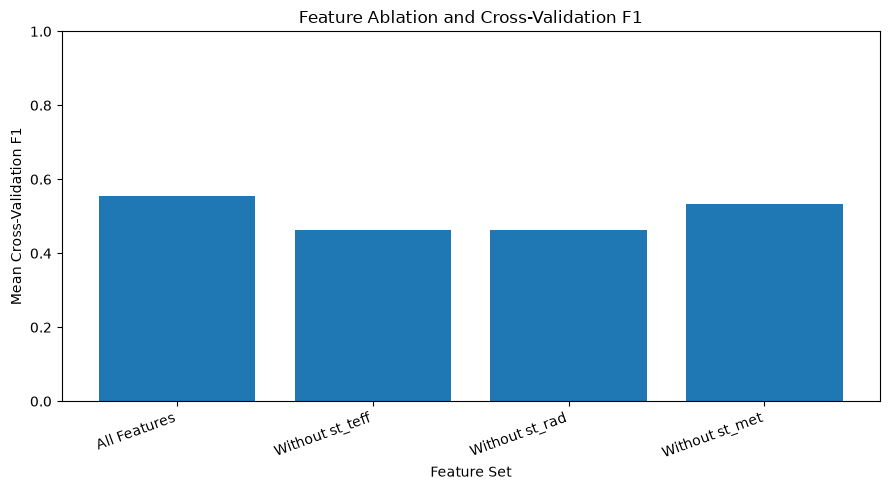

In [45]:
plt.figure(figsize=(9, 5))

plt.bar(
    ablation_results[
        "Feature Set"
    ],
    ablation_results[
        "F1"
    ]
)

plt.xlabel(
    "Feature Set"
)

plt.ylabel(
    "Mean Cross-Validation F1"
)

plt.title(
    "Feature Ablation and Cross-Validation F1"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

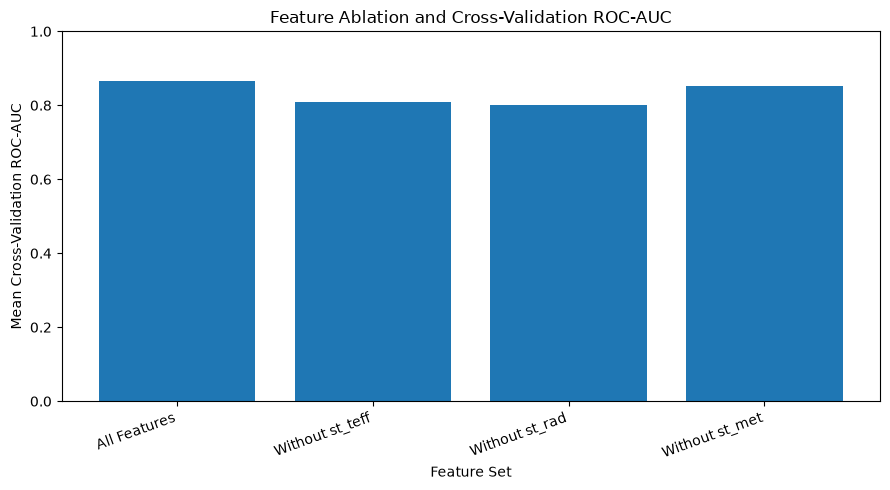

In [46]:
plt.figure(figsize=(9, 5))

plt.bar(
    ablation_results[
        "Feature Set"
    ],
    ablation_results[
        "ROC-AUC"
    ]
)

plt.xlabel(
    "Feature Set"
)

plt.ylabel(
    "Mean Cross-Validation ROC-AUC"
)

plt.title(
    "Feature Ablation and Cross-Validation ROC-AUC"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

# Single-Feature and Feature-Combination Models

Feature ablation asks what happens when a feature is removed from the complete model.

This analysis asks a complementary question:

> How much predictive information is contained in each feature individually, and how does performance change as features are combined?

The following feature sets are evaluated:

### Single features

- st_teff
- st_rad
- st_met

### Two-feature combinations

- st_teff + st_rad
- st_teff + st_met
- st_rad + st_met

### Complete feature set

- st_teff + st_rad + st_met

All models use the same fixed Random Forest configuration and the same cross-validation procedure.

This analysis helps distinguish between:

- individually predictive features,
- complementary features,
- and potentially redundant information.

In [47]:
feature_sets_combinations = {
    "st_teff": [
        "st_teff"
    ],

    "st_rad": [
        "st_rad"
    ],

    "st_met": [
        "st_met"
    ],

    "st_teff + st_rad": [
        "st_teff",
        "st_rad"
    ],

    "st_teff + st_met": [
        "st_teff",
        "st_met"
    ],

    "st_rad + st_met": [
        "st_rad",
        "st_met"
    ],

    "All Three Features": [
        "st_teff",
        "st_rad",
        "st_met"
    ]
}

feature_sets_combinations

{'st_teff': ['st_teff'],
 'st_rad': ['st_rad'],
 'st_met': ['st_met'],
 'st_teff + st_rad': ['st_teff', 'st_rad'],
 'st_teff + st_met': ['st_teff', 'st_met'],
 'st_rad + st_met': ['st_rad', 'st_met'],
 'All Three Features': ['st_teff', 'st_rad', 'st_met']}

In [48]:
combination_results = []

for feature_set_name, feature_list in feature_sets_combinations.items():

    model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    **final_rf_parameters
                )
            )
        ]
    )

    results = cross_validate(
        model,
        X[feature_list],
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    combination_results.append({
        "Feature Set": feature_set_name,
        "Number of Features": len(feature_list),
        "Accuracy": results[
            "test_accuracy"
        ].mean(),

        "Precision": results[
            "test_precision"
        ].mean(),

        "Recall": results[
            "test_recall"
        ].mean(),

        "F1": results[
            "test_f1"
        ].mean(),

        "ROC-AUC": results[
            "test_roc_auc"
        ].mean(),

        "Average Precision": results[
            "test_average_precision"
        ].mean()
    })

combination_results = pd.DataFrame(
    combination_results
)

combination_results.round(4)

,Feature Set,Number of Features,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,st_teff,1,0.6809,0.2672,0.6543,0.3795,0.7206,0.3666
1,st_rad,1,0.7023,0.2753,0.6093,0.3791,0.7178,0.3624
2,st_met,1,0.5179,0.1997,0.7415,0.3146,0.6604,0.2684
3,st_teff + st_rad,2,0.8459,0.4866,0.5935,0.5345,0.8531,0.5646
4,st_teff + st_met,2,0.7825,0.3667,0.6307,0.4636,0.8003,0.5056
5,st_rad + st_met,2,0.7926,0.3767,0.5971,0.4617,0.8083,0.4795
6,All Three Features,3,0.8581,0.5229,0.5898,0.5537,0.8648,0.5805


In [49]:
combination_results_sorted = (
    combination_results
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

combination_results_sorted.round(4)

,Feature Set,Number of Features,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,All Three Features,3,0.8581,0.5229,0.5898,0.5537,0.8648,0.5805
1,st_teff + st_rad,2,0.8459,0.4866,0.5935,0.5345,0.8531,0.5646
2,st_teff + st_met,2,0.7825,0.3667,0.6307,0.4636,0.8003,0.5056
3,st_rad + st_met,2,0.7926,0.3767,0.5971,0.4617,0.8083,0.4795
4,st_teff,1,0.6809,0.2672,0.6543,0.3795,0.7206,0.3666
5,st_rad,1,0.7023,0.2753,0.6093,0.3791,0.7178,0.3624
6,st_met,1,0.5179,0.1997,0.7415,0.3146,0.6604,0.2684


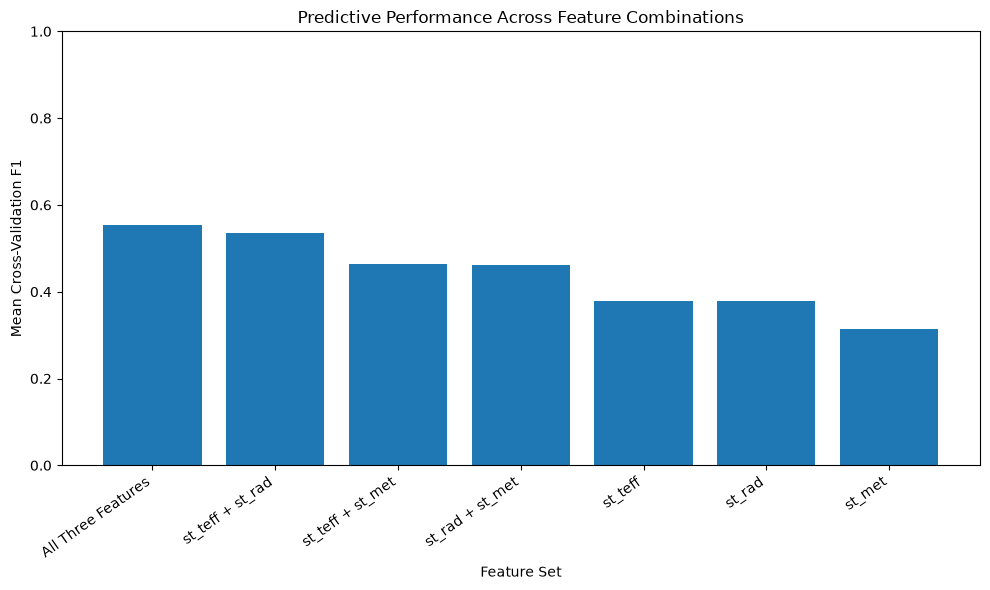

In [50]:
plt.figure(figsize=(10, 6))

plt.bar(
    combination_results_sorted[
        "Feature Set"
    ],
    combination_results_sorted[
        "F1"
    ]
)

plt.xlabel(
    "Feature Set"
)

plt.ylabel(
    "Mean Cross-Validation F1"
)

plt.title(
    "Predictive Performance Across Feature Combinations"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

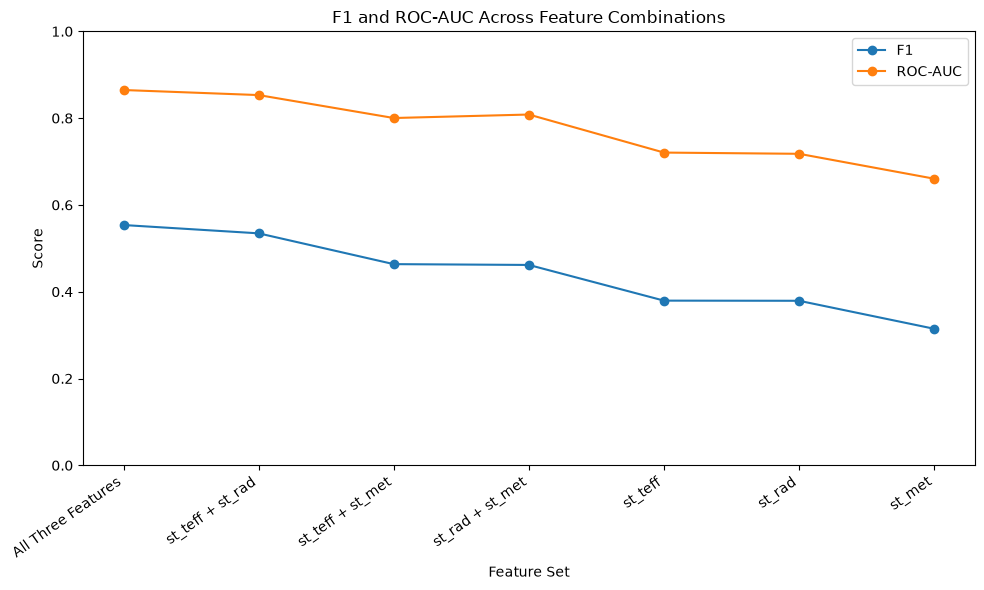

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    combination_results_sorted[
        "Feature Set"
    ],
    combination_results_sorted[
        "F1"
    ],
    marker="o",
    label="F1"
)

plt.plot(
    combination_results_sorted[
        "Feature Set"
    ],
    combination_results_sorted[
        "ROC-AUC"
    ],
    marker="o",
    label="ROC-AUC"
)

plt.xlabel(
    "Feature Set"
)

plt.ylabel(
    "Score"
)

plt.title(
    "F1 and ROC-AUC Across Feature Combinations"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()

plt.show()

# SHAP Analysis

SHAP analysis provides another perspective on model interpretation.

The analysis examines:

1. **Global feature importance**  
   Which features contribute most strongly to the model's predictions overall?

2. **Direction of feature influence**  
   Do higher or lower feature values tend to push predictions toward the gas-giant class?

3. **Individual predictions**  
   How do the features contribute to specific observations?

SHAP explanations describe the behavior of the fitted model.

They do not establish that a feature causally determines planetary composition.

Because the Random Forest is trained inside a preprocessing pipeline, the fitted Random Forest estimator is extracted before SHAP analysis.

In [52]:
import shap

In [53]:
rf_model = best_model.named_steps[
    "model"
]

rf_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [54]:
explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_test
)

In [55]:
if isinstance(
    shap_values,
    list
):

    shap_values_positive = (
        shap_values[1]
    )

elif len(shap_values.shape) == 3:

    shap_values_positive = (
        shap_values[:, :, 1]
    )

else:

    shap_values_positive = (
        shap_values
    )

print(
    "SHAP values shape:",
    shap_values_positive.shape
)

print(
    "Feature matrix shape:",
    X_test.shape
)

assert (
    shap_values_positive.shape
    == X_test.shape
)

SHAP values shape: (5508, 3)
Feature matrix shape: (5508, 3)


## Global SHAP Feature Importance

Mean absolute SHAP value measures the average magnitude of a feature's contribution to the model's predictions.

A larger value indicates that the feature generally has a greater influence on the model's output.

This is a measure of model contribution, not causal importance.

In [56]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP Value": np.abs(
        shap_values_positive
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean Absolute SHAP Value",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.round(4)

,Feature,Mean Absolute SHAP Value
0,st_rad,0.1633
1,st_teff,0.1303
2,st_met,0.1031


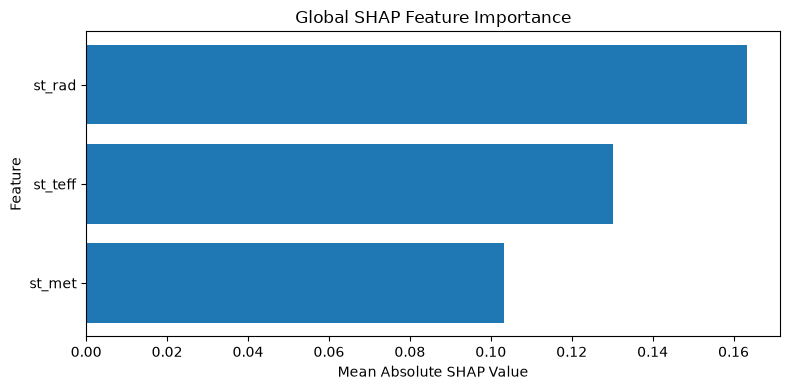

In [57]:
plt.figure(figsize=(8, 4))

plt.barh(
    shap_importance[
        "Feature"
    ],
    shap_importance[
        "Mean Absolute SHAP Value"
    ]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

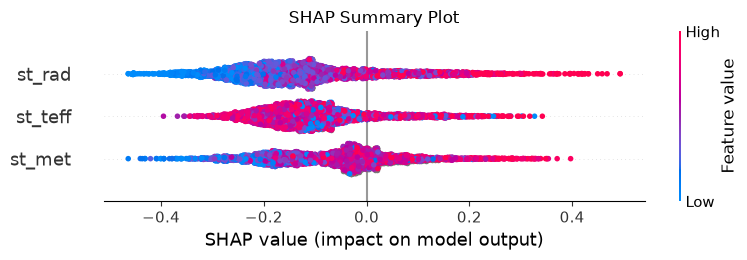

In [58]:
shap.summary_plot(
    shap_values_positive,
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.title(
    "SHAP Summary Plot"
)

plt.tight_layout()

plt.show()

## SHAP Dependence Analysis

SHAP dependence plots show how the value of an individual feature relates to its contribution to the model's prediction.

The vertical axis represents the feature's SHAP contribution.

Positive SHAP values indicate that the feature contribution pushes the prediction toward the gas-giant class.

Negative SHAP values indicate that the feature contribution pushes the prediction away from the gas-giant class.

These relationships describe the fitted model's behavior and should not be interpreted as causal effects.

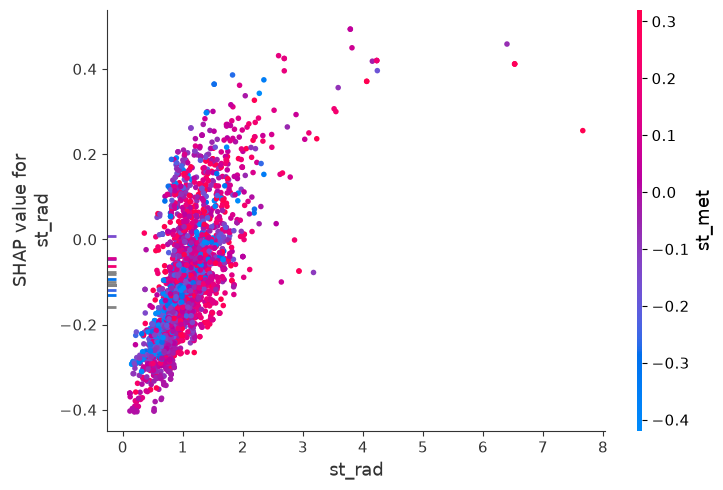

In [59]:
top_shap_feature = (
    shap_importance
    .iloc[0]["Feature"]
)

shap.dependence_plot(
    top_shap_feature,
    shap_values_positive,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

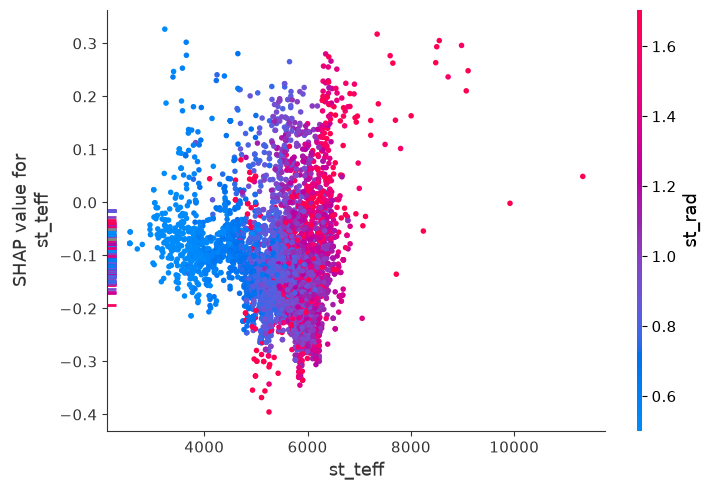

In [60]:
shap.dependence_plot(
    "st_teff",
    shap_values_positive,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

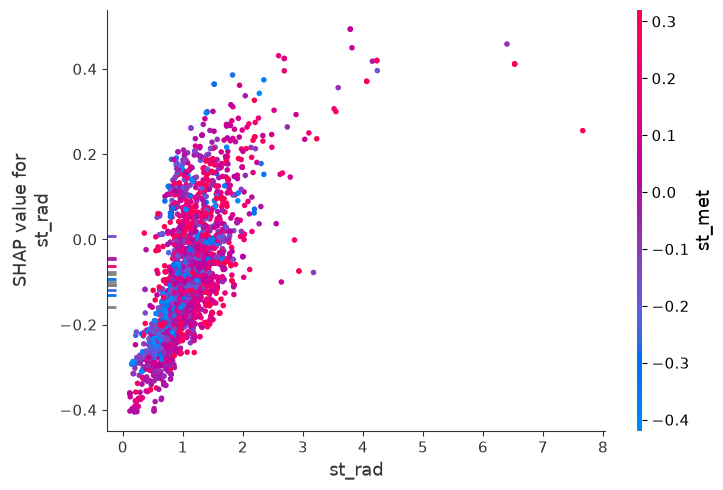

In [61]:
shap.dependence_plot(
    "st_rad",
    shap_values_positive,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

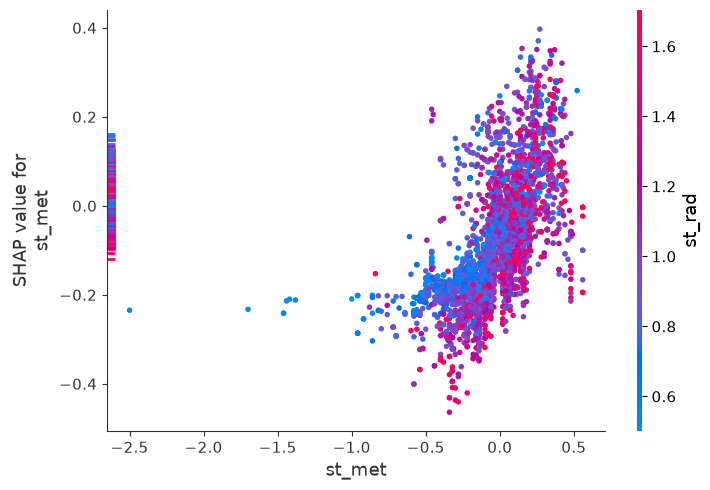

In [62]:
shap.dependence_plot(
    "st_met",
    shap_values_positive,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

## Individual Prediction Explanations

Global feature importance describes average model behavior.

Individual SHAP values can reveal why a particular observation received a specific prediction.

The following analysis examines one observation from the test set.

The selected observation is shown with its feature values, actual class, predicted class, and predicted gas-giant probability.

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [64]:
def create_model_pipeline(
    feature_subset,
    random_state=42
):

    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=random_state,
                n_jobs=-1
            )
        )
    ])

In [68]:
individual_index = 0


In [71]:
individual_index = 0

individual_observation = X_test.iloc[
    individual_index
]

individual_prediction = rf_model.predict(
    X_test
)[individual_index]

individual_probability = rf_model.predict_proba(
    X_test
)[individual_index, 1]

print(
    "Individual observation:"
)

display(
    individual_observation.to_frame(
        name="Value"
    )
)

print(
    "Predicted class:",
    individual_prediction
)

print(
    "Gas-giant probability:",
    round(
        individual_probability,
        3
    )
)

Individual observation:


c:\Users\bhara\projects\exoplanet-classification-ml\exoplanet-classification-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\bhara\projects\exoplanet-classification-ml\exoplanet-classification-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Value
st_teff,5400.00000
st_rad,1.09539
st_met,NaN


Predicted class: 1
Gas-giant probability: 0.681


In [72]:
individual_shap_values = (
    shap_values_positive[
        individual_index
    ]
)

individual_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": X_test.iloc[
        individual_index
    ].values,
    "SHAP Contribution": individual_shap_values
})

individual_explanation[
    "Absolute Contribution"
] = abs(
    individual_explanation[
        "SHAP Contribution"
    ]
)

individual_explanation = (
    individual_explanation
    .sort_values(
        "Absolute Contribution",
        ascending=False
    )
    .reset_index(drop=True)
)

individual_explanation.round(4)

,Feature,Feature Value,SHAP Contribution,Absolute Contribution
0,st_teff,5400.0000,0.0904,0.0904
1,st_met,NaN,0.0595,0.0595
2,st_rad,1.0954,0.0307,0.0307


# Direct Analysis of the Astronomical Data

The previous analyses investigated the behavior of machine-learning models.

This section steps away from the model.

The purpose is to examine whether the underlying dataset itself contains observable differences between:

- Gas giants
- Non-gas giants

For each host-star feature, the analysis examines:

- Distribution differences
- Median values
- Interquartile ranges
- Binned observed gas-giant frequencies

This distinction is scientifically important.

A model may learn a predictive pattern that is present in the dataset.

However, a model's feature importance alone does not show the actual structure of the underlying observations.

Direct data analysis allows us to compare:

> The model learned this predictive pattern.

with:

> The dataset itself contains an observable association.

In [73]:
direct_analysis = X.copy()

direct_analysis[
    "Target"
] = y.values

direct_analysis[
    "Class Label"
] = direct_analysis[
    "Target"
].map({
    0: "Non-Gas Giant",
    1: "Gas Giant"
})

direct_analysis.head()

,st_teff,st_rad,st_met,Target,Class Label
0,5853.0,0.890,NaN,0,Non-Gas Giant
1,6018.0,0.940,NaN,1,Gas Giant
2,6168.0,1.240,0.03,0,Non-Gas Giant
3,6297.0,1.369,0.14,0,Non-Gas Giant
4,5783.0,0.842,-0.28,0,Non-Gas Giant


In [74]:
distribution_summary = []

for feature in FEATURES:

    gas_giants = direct_analysis.loc[
        direct_analysis["Target"] == 1,
        feature
    ]

    non_gas_giants = direct_analysis.loc[
        direct_analysis["Target"] == 0,
        feature
    ]

    distribution_summary.append({
        "Feature": feature,

        "Gas Giant Median":
            gas_giants.median(),

        "Gas Giant Q1":
            gas_giants.quantile(0.25),

        "Gas Giant Q3":
            gas_giants.quantile(0.75),

        "Non-Gas Giant Median":
            non_gas_giants.median(),

        "Non-Gas Giant Q1":
            non_gas_giants.quantile(0.25),

        "Non-Gas Giant Q3":
            non_gas_giants.quantile(0.75)
    })

distribution_summary = pd.DataFrame(
    distribution_summary
)

distribution_summary.round(3)

,Feature,Gas Giant Median,Gas Giant Q1,Gas Giant Q3,Non-Gas Giant Median,Non-Gas Giant Q1,Non-Gas Giant Q3
0,st_teff,5791.000,5403.50,6146.00,5612.00,5080.00,5949.000
1,st_rad,1.142,0.91,1.52,0.91,0.76,1.101
2,st_met,0.080,-0.04,0.21,-0.04,-0.18,0.070


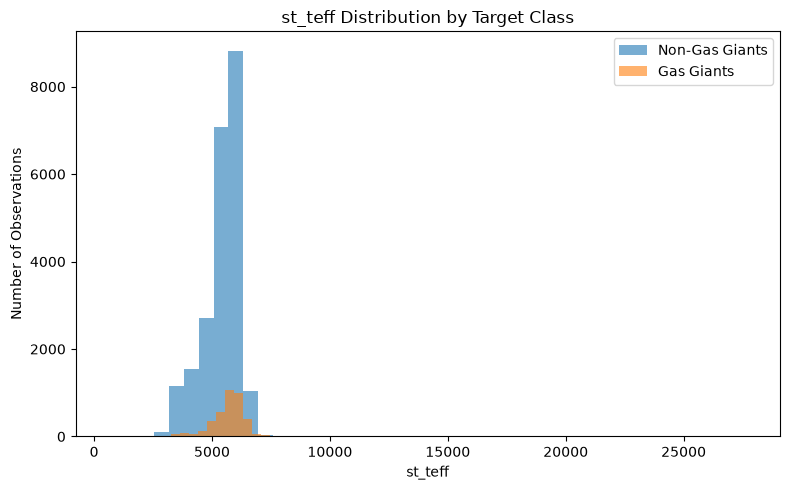

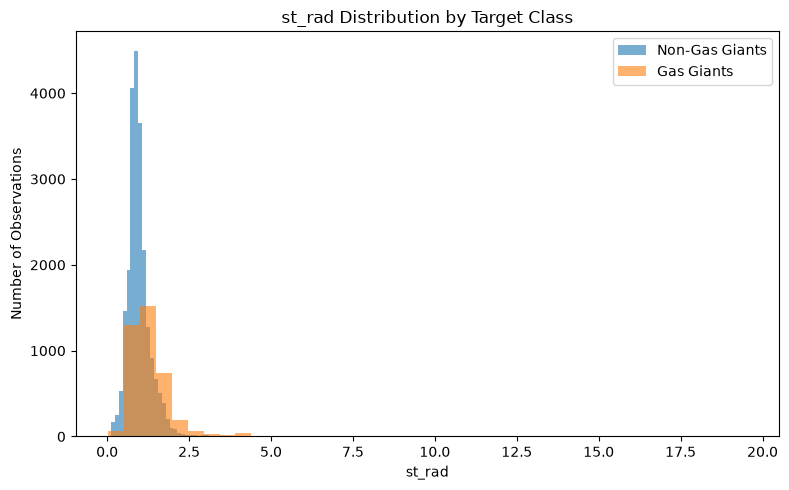

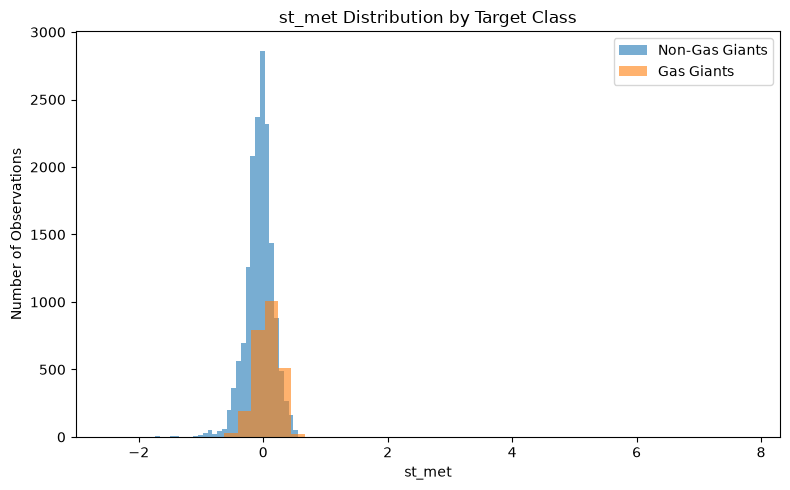

In [75]:
for feature in FEATURES:

    plt.figure(figsize=(8, 5))

    plt.hist(
        direct_analysis.loc[
            direct_analysis["Target"] == 0,
            feature
        ],
        bins=40,
        alpha=0.6,
        label="Non-Gas Giants"
    )

    plt.hist(
        direct_analysis.loc[
            direct_analysis["Target"] == 1,
            feature
        ],
        bins=40,
        alpha=0.6,
        label="Gas Giants"
    )

    plt.xlabel(
        feature
    )

    plt.ylabel(
        "Number of Observations"
    )

    plt.title(
        f"{feature} Distribution by Target Class"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

## Binned Gas-Giant Frequency

For each host-star feature, observations are divided into quantile-based bins.

For each bin, the observed fraction of gas giants is calculated.

This analysis asks:

> Does the observed gas-giant frequency vary across the range of a stellar property?

Quantile bins are used so that each region contains a broadly comparable number of observations.

These observed frequencies describe associations in the dataset and do not establish causation.

In [76]:
binned_frequency_results = {}

for feature in FEATURES:

    temp = direct_analysis[
        [
            feature,
            "Target"
        ]
    ].copy()

    temp[
        "Feature Bin"
    ] = pd.qcut(
        temp[feature],
        q=10,
        duplicates="drop"
    )

    grouped = (
        temp
        .groupby(
            "Feature Bin",
            observed=True
        )
        .agg(
            Observations=(
                "Target",
                "count"
            ),

            Gas_Giants=(
                "Target",
                "sum"
            ),

            Gas_Giant_Frequency=(
                "Target",
                "mean"
            ),

            Mean_Feature_Value=(
                feature,
                "mean"
            )
        )
        .reset_index()
    )

    binned_frequency_results[
        feature
    ] = grouped

binned_frequency_results[
    "st_teff"
].round(4)

,Feature Bin,Observations,Gas_Giants,Gas_Giant_Frequency,Mean_Feature_Value
0,"(574.999, 4252.0]",2642,187,0.0708,3754.7887
1,"(4252.0, 4960.0]",2638,265,0.1005,4682.6238
2,"(4960.0, 5242.0]",2634,288,0.1093,5114.3426
3,"(5242.0, 5477.0]",2638,328,0.1243,5362.9034
4,"(5477.0, 5641.0]",2659,427,0.1606,5562.5117
5,"(5641.0, 5774.0]",2613,391,0.1496,5710.1162
6,"(5774.0, 5906.0]",2640,342,0.1295,5840.9126
7,"(5906.0, 6052.0]",2635,431,0.1636,5979.6820
8,"(6052.0, 6220.0]",2648,431,0.1628,6132.5930
9,"(6220.0, 27730.0]",2624,769,0.2931,6504.4766


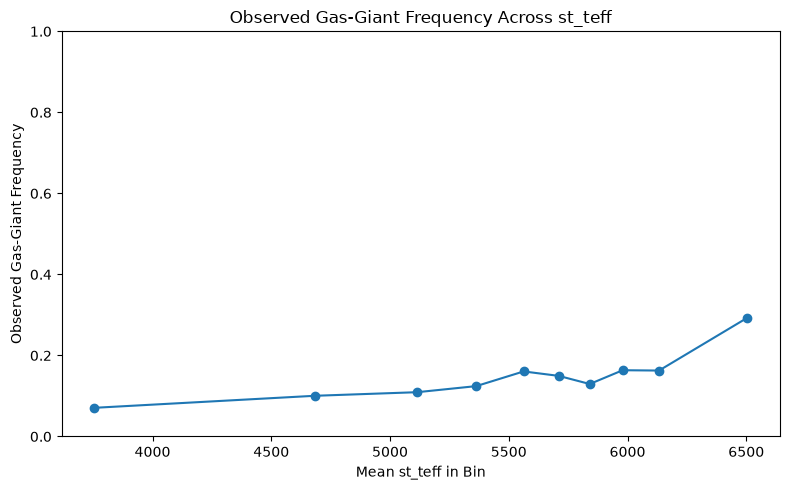

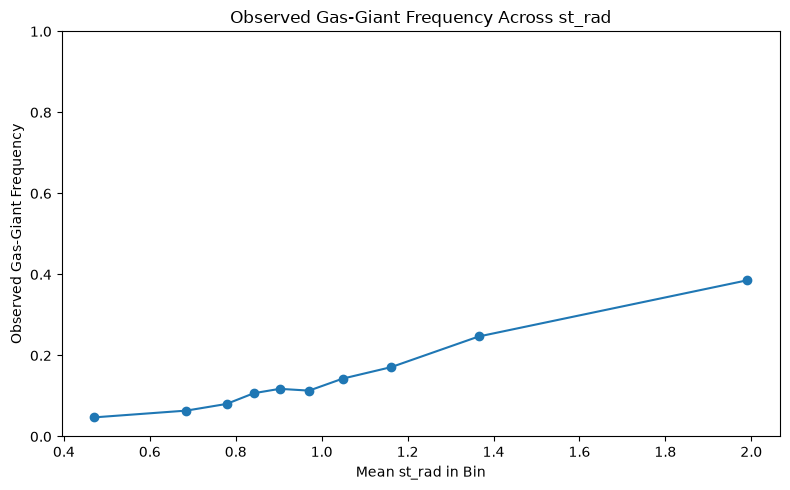

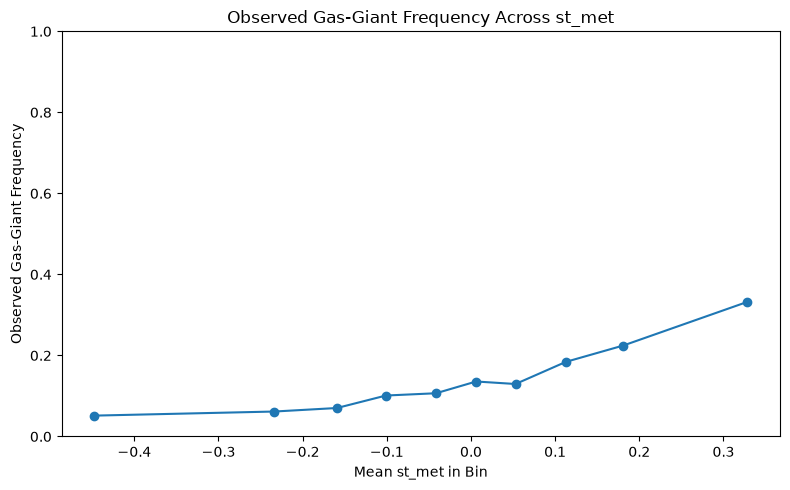

In [77]:
for feature in FEATURES:

    grouped = binned_frequency_results[
        feature
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        grouped[
            "Mean_Feature_Value"
        ],
        grouped[
            "Gas_Giant_Frequency"
        ],
        marker="o"
    )

    plt.xlabel(
        f"Mean {feature} in Bin"
    )

    plt.ylabel(
        "Observed Gas-Giant Frequency"
    )

    plt.title(
        f"Observed Gas-Giant Frequency Across {feature}"
    )

    plt.ylim(0, 1)

    plt.tight_layout()

    plt.show()

# Interpretation Agreement

The final section compares evidence from several independent analyses.

The goal is not to force identical feature rankings.

Different methods answer slightly different questions:

- Random Forest impurity importance measures internal tree-based impurity reduction.
- Permutation importance measures performance loss when a feature is shuffled.
- SHAP measures the magnitude of feature contributions to individual predictions.
- Feature ablation measures performance change after removing a feature.
- Feature-combination models measure predictive information contained in individual and combined feature sets.
- Direct data analysis measures observable associations in the underlying dataset.

If multiple methods broadly identify the same feature as important, confidence in the interpretation increases.

If methods disagree, the disagreement itself is informative.

It may reflect:

- Feature correlation
- Redundant information
- Nonlinear relationships
- Model-specific behavior
- Different statistical questions being measured

The final interpretation should therefore consider the complete body of evidence rather than relying on a single importance ranking.

In [78]:
rf_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "RF Impurity Importance":
        best_model
        .named_steps[
            "model"
        ]
        .feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "RF Impurity Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_importance

,Feature,RF Impurity Importance
0,st_rad,0.408478
1,st_teff,0.383826
2,st_met,0.207696


## Final Interpretation

The feature contribution analyses provide multiple perspectives on the predictive structure of the dataset.

Random Forest impurity importance, permutation importance, SHAP analysis, feature ablation, feature-combination models, and direct analysis of the observed astronomical data do not necessarily measure the same quantity. Therefore, exact agreement between their feature rankings is not expected.

Instead, interpretation confidence is strengthened when multiple independent approaches broadly identify similar predictive patterns.

Agreement between model-based methods suggests that the pattern is not solely an artifact of one particular interpretation technique. Agreement between model-based methods and direct data analysis further suggests that the model is responding to observable associations present in the underlying dataset.

However, these analyses remain observational and predictive. Feature importance and predictive association do not establish causation.

The final scientific interpretation should therefore be based on the combined evidence:

- which features contribute to model predictions,
- whether removing them reduces predictive performance,
- whether they are individually predictive,
- whether they provide complementary information,
- whether independent interpretation methods broadly agree,
- and whether similar patterns are visible directly in the astronomical data.

The results from this notebook will be combined with the calibration, generalization, subgroup, and robustness analyses in the final scientific synthesis.

In [79]:
rf_importance["RF Importance Rank"] = (
    rf_importance[
        "RF Impurity Importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

rf_importance

,Feature,RF Impurity Importance,RF Importance Rank
0,st_rad,0.408478,1
1,st_teff,0.383826,2
2,st_met,0.207696,3


In [80]:
from sklearn.inspection import permutation_importance

# Fit the final Random Forest on the complete modeling dataset

permutation_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "model",
            RandomForestClassifier(
                **final_rf_parameters
            )
        )
    ]
)

permutation_model.fit(
    X,
    y
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['st_teff','st_rad','st_met']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `Non

In [81]:
permutation_results = permutation_importance(
    permutation_model,
    X,
    y,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance Mean":
        permutation_results.importances_mean,
    "Permutation Importance Std":
        permutation_results.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "Permutation Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df[
    "Permutation Importance Rank"
] = (
    permutation_importance_df[
        "Permutation Importance Mean"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

permutation_importance_df.round(4)

,Feature,Permutation Importance Mean,Permutation Importance Std,Permutation Importance Rank
0,st_rad,0.5933,0.0026,1
1,st_teff,0.5334,0.0039,2
2,st_met,0.4516,0.0051,3


In [82]:
shap_importance[
    "SHAP Importance Rank"
] = (
    shap_importance[
        "Mean Absolute SHAP Value"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

shap_importance

,Feature,Mean Absolute SHAP Value,SHAP Importance Rank
0,st_rad,0.163311,1
1,st_teff,0.130269,2
2,st_met,0.103148,3


In [83]:
ablation_impact = pd.DataFrame({
    "Feature": FEATURES
})

ablation_impact[
    "F1 Loss When Removed"
] = [
    reference_f1
    -
    ablation_results.loc[
        ablation_results[
            "Feature Set"
        ]
        ==
        f"Without {feature}",
        "F1"
    ].iloc[0]

    for feature in FEATURES
]

ablation_impact[
    "ROC-AUC Loss When Removed"
] = [
    reference_roc_auc
    -
    ablation_results.loc[
        ablation_results[
            "Feature Set"
        ]
        ==
        f"Without {feature}",
        "ROC-AUC"
    ].iloc[0]

    for feature in FEATURES
]

ablation_impact[
    "Ablation F1 Impact Rank"
] = (
    ablation_impact[
        "F1 Loss When Removed"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

ablation_impact.round(4)

,Feature,F1 Loss When Removed,ROC-AUC Loss When Removed,Ablation F1 Impact Rank
0,st_teff,0.0920,0.0565,1
1,st_rad,0.0901,0.0645,2
2,st_met,0.0191,0.0117,3


In [84]:
single_feature_results = (
    combination_results[
        combination_results[
            "Number of Features"
        ]
        == 1
    ]
    .copy()
)

single_feature_results[
    "Single-Feature F1 Rank"
] = (
    single_feature_results[
        "F1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

single_feature_results[
    [
        "Feature Set",
        "F1",
        "ROC-AUC",
        "Single-Feature F1 Rank"
    ]
].round(4)

,Feature Set,F1,ROC-AUC,Single-Feature F1 Rank
0,st_teff,0.3795,0.7206,1
1,st_rad,0.3791,0.7178,2
2,st_met,0.3146,0.6604,3


In [85]:
direct_data_evidence = distribution_summary.copy()

direct_data_evidence[
    "Median Difference"
] = (
    direct_data_evidence[
        "Gas Giant Median"
    ]
    -
    direct_data_evidence[
        "Non-Gas Giant Median"
    ]
)

direct_data_evidence[
    "Absolute Median Difference"
] = abs(
    direct_data_evidence[
        "Median Difference"
    ]
)

direct_data_evidence[
    "Direct Data Association Rank"
] = (
    direct_data_evidence[
        "Absolute Median Difference"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

direct_data_evidence[
    [
        "Feature",
        "Gas Giant Median",
        "Non-Gas Giant Median",
        "Median Difference",
        "Direct Data Association Rank"
    ]
].round(4)

,Feature,Gas Giant Median,Non-Gas Giant Median,Median Difference,Direct Data Association Rank
0,st_teff,5791.000,5612.00,179.000,1
1,st_rad,1.142,0.91,0.232,2
2,st_met,0.080,-0.04,0.120,3


In [86]:
binned_pattern_evidence = []

for feature in FEATURES:

    grouped = binned_frequency_results[
        feature
    ]

    frequency_range = (
        grouped[
            "Gas_Giant_Frequency"
        ].max()
        -
        grouped[
            "Gas_Giant_Frequency"
        ].min()
    )

    binned_pattern_evidence.append({
        "Feature": feature,

        "Minimum Gas-Giant Frequency":
            grouped[
                "Gas_Giant_Frequency"
            ].min(),

        "Maximum Gas-Giant Frequency":
            grouped[
                "Gas_Giant_Frequency"
            ].max(),

        "Frequency Range":
            frequency_range
    })

binned_pattern_evidence = pd.DataFrame(
    binned_pattern_evidence
)

binned_pattern_evidence[
    "Direct Pattern Strength Rank"
] = (
    binned_pattern_evidence[
        "Frequency Range"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

binned_pattern_evidence.round(4)

,Feature,Minimum Gas-Giant Frequency,Maximum Gas-Giant Frequency,Frequency Range,Direct Pattern Strength Rank
0,st_teff,0.0708,0.2931,0.2223,3
1,st_rad,0.0472,0.3856,0.3384,1
2,st_met,0.0515,0.3322,0.2807,2


In [87]:
interpretation_agreement = (
    rf_importance[
        [
            "Feature",
            "RF Impurity Importance",
            "RF Importance Rank"
        ]
    ]
    .merge(
        permutation_importance_df[
            [
                "Feature",
                "Permutation Importance Mean",
                "Permutation Importance Std",
                "Permutation Importance Rank"
            ]
        ],
        on="Feature"
    )
    .merge(
        shap_importance[
            [
                "Feature",
                "Mean Absolute SHAP Value",
                "SHAP Importance Rank"
            ]
        ],
        on="Feature"
    )
    .merge(
        ablation_impact[
            [
                "Feature",
                "F1 Loss When Removed",
                "ROC-AUC Loss When Removed",
                "Ablation F1 Impact Rank"
            ]
        ],
        on="Feature"
    )
)

In [88]:
single_feature_evidence = (
    single_feature_results[
        [
            "Feature Set",
            "F1",
            "ROC-AUC",
            "Single-Feature F1 Rank"
        ]
    ]
    .rename(
        columns={
            "Feature Set": "Feature",
            "F1": "Single-Feature F1",
            "ROC-AUC": "Single-Feature ROC-AUC"
        }
    )
)

interpretation_agreement = (
    interpretation_agreement
    .merge(
        single_feature_evidence,
        on="Feature"
    )
)

interpretation_agreement.round(4)

,Feature,RF Impurity Importance,RF Importance Rank,Permutation Importance Mean,Permutation Importance Std,Permutation Importance Rank,Mean Absolute SHAP Value,SHAP Importance Rank,F1 Loss When Removed,ROC-AUC Loss When Removed,Ablation F1 Impact Rank,Single-Feature F1,Single-Feature ROC-AUC,Single-Feature F1 Rank
0,st_rad,0.4085,1,0.5933,0.0026,1,0.1633,1,0.0901,0.0645,2,0.3791,0.7178,2
1,st_teff,0.3838,2,0.5334,0.0039,2,0.1303,2,0.0920,0.0565,1,0.3795,0.7206,1
2,st_met,0.2077,3,0.4516,0.0051,3,0.1031,3,0.0191,0.0117,3,0.3146,0.6604,3


In [89]:
interpretation_agreement = (
    interpretation_agreement
    .merge(
        binned_pattern_evidence[
            [
                "Feature",
                "Frequency Range",
                "Direct Pattern Strength Rank"
            ]
        ],
        on="Feature"
    )
)

interpretation_agreement.round(4)

,Feature,RF Impurity Importance,RF Importance Rank,Permutation Importance Mean,Permutation Importance Std,Permutation Importance Rank,Mean Absolute SHAP Value,SHAP Importance Rank,F1 Loss When Removed,ROC-AUC Loss When Removed,Ablation F1 Impact Rank,Single-Feature F1,Single-Feature ROC-AUC,Single-Feature F1 Rank,Frequency Range,Direct Pattern Strength Rank
0,st_rad,0.4085,1,0.5933,0.0026,1,0.1633,1,0.0901,0.0645,2,0.3791,0.7178,2,0.3384,1
1,st_teff,0.3838,2,0.5334,0.0039,2,0.1303,2,0.0920,0.0565,1,0.3795,0.7206,1,0.2223,3
2,st_met,0.2077,3,0.4516,0.0051,3,0.1031,3,0.0191,0.0117,3,0.3146,0.6604,3,0.2807,2


In [90]:
rank_comparison = interpretation_agreement[
    [
        "Feature",
        "RF Importance Rank",
        "Permutation Importance Rank",
        "SHAP Importance Rank",
        "Ablation F1 Impact Rank",
        "Single-Feature F1 Rank",
        "Direct Pattern Strength Rank"
    ]
].copy()

rank_comparison

,Feature,RF Importance Rank,Permutation Importance Rank,SHAP Importance Rank,Ablation F1 Impact Rank,Single-Feature F1 Rank,Direct Pattern Strength Rank
0,st_rad,1,1,1,2,2,1
1,st_teff,2,2,2,1,1,3
2,st_met,3,3,3,3,3,2


In [91]:
rank_columns = [
    "RF Importance Rank",
    "Permutation Importance Rank",
    "SHAP Importance Rank",
    "Ablation F1 Impact Rank",
    "Single-Feature F1 Rank",
    "Direct Pattern Strength Rank"
]

rank_comparison[
    "Mean Evidence Rank"
] = (
    rank_comparison[
        rank_columns
    ]
    .mean(axis=1)
)

rank_comparison = (
    rank_comparison
    .sort_values(
        "Mean Evidence Rank"
    )
    .reset_index(drop=True)
)

rank_comparison

,Feature,RF Importance Rank,Permutation Importance Rank,SHAP Importance Rank,Ablation F1 Impact Rank,Single-Feature F1 Rank,Direct Pattern Strength Rank,Mean Evidence Rank
0,st_rad,1,1,1,2,2,1,1.333333
1,st_teff,2,2,2,1,1,3,1.833333
2,st_met,3,3,3,3,3,2,2.833333


<Figure size 1000x600 with 0 Axes>

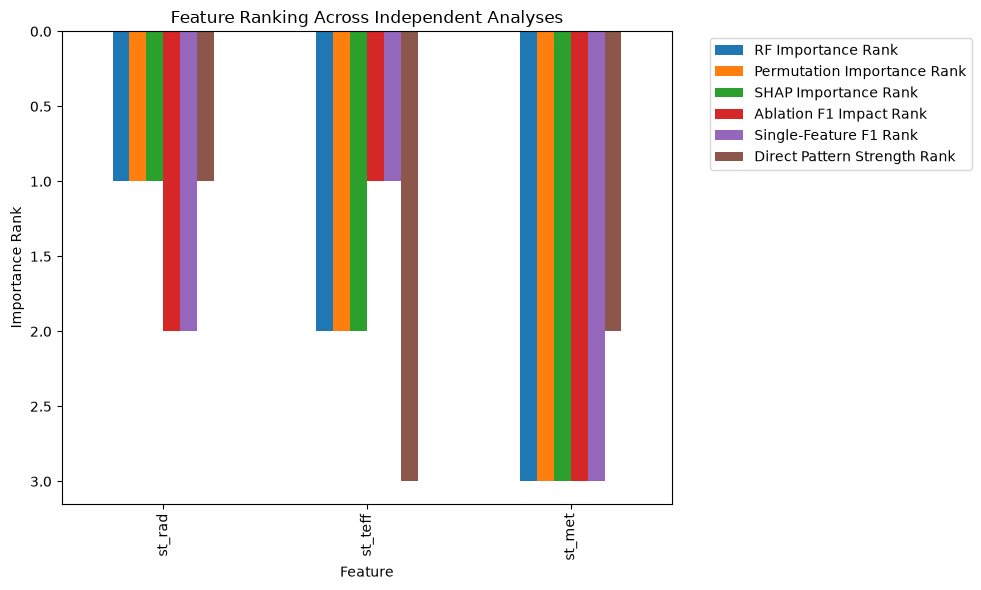

In [92]:
plt.figure(figsize=(10, 6))

rank_plot_data = (
    rank_comparison
    .set_index("Feature")[
        rank_columns
    ]
)

rank_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Importance Rank"
)

plt.title(
    "Feature Ranking Across Independent Analyses"
)

plt.gca().invert_yaxis()

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [93]:
print(
    "Interpretation Agreement Summary"
)

print(
    "==============================="
)

for _, row in rank_comparison.iterrows():

    print(
        f"\n{row['Feature']}"
    )

    print(
        f"  RF importance rank: "
        f"{int(row['RF Importance Rank'])}"
    )

    print(
        f"  Permutation importance rank: "
        f"{int(row['Permutation Importance Rank'])}"
    )

    print(
        f"  SHAP importance rank: "
        f"{int(row['SHAP Importance Rank'])}"
    )

    print(
        f"  Ablation impact rank: "
        f"{int(row['Ablation F1 Impact Rank'])}"
    )

    print(
        f"  Single-feature F1 rank: "
        f"{int(row['Single-Feature F1 Rank'])}"
    )

    print(
        f"  Direct pattern rank: "
        f"{int(row['Direct Pattern Strength Rank'])}"
    )

    print(
        f"  Mean evidence rank: "
        f"{row['Mean Evidence Rank']:.2f}"
    )

Interpretation Agreement Summary

st_rad
  RF importance rank: 1
  Permutation importance rank: 1
  SHAP importance rank: 1
  Ablation impact rank: 2
  Single-feature F1 rank: 2
  Direct pattern rank: 1
  Mean evidence rank: 1.33

st_teff
  RF importance rank: 2
  Permutation importance rank: 2
  SHAP importance rank: 2
  Ablation impact rank: 1
  Single-feature F1 rank: 1
  Direct pattern rank: 3
  Mean evidence rank: 1.83

st_met
  RF importance rank: 3
  Permutation importance rank: 3
  SHAP importance rank: 3
  Ablation impact rank: 3
  Single-feature F1 rank: 3
  Direct pattern rank: 2
  Mean evidence rank: 2.83
